# 03 Swap Tolerance

This is a model of a single neuron's **dendrite** — the branched input cable that collects signals from other neurons. We split the dendrite into 12 small compartments ("segments") laid out in a line. Each segment carries two competing ion channels:

- **NMDA**, which is *regenerative*: once a segment depolarizes, NMDA pushes it further up and holds it there (a self-sustaining "plateau").
- **KIR**, which is *restoring*: it pulls a segment back down toward rest.

The balance between the two parameters makes up the **NMDA/KIR ratio** and it decides how easily a segment latches into the "up" state and stays there. We'll alter this ratio for testing later on in this notebook.

### The task: detecting a sequence

We feed the dendrite an input **sequence**: brief bursts of excitation arriving at segments 5, then 6, then 7, then 8, staggered slightly in time. A good sequence detector should light those segments up *in that order*, like a wave traveling 5 → 6 → 7 → 8.

Real input is jittery, so:

1. If two neighboring elements arrive in the "wrong" order (a small local **swap**, e.g. 6 just before 5), should the detector still accept it? Ideally **yes** because that is harmless timing jitter, and the gist of the sequence is intact.
2. If the whole sequence is **reversed** (8 → 7 → 6 → 5), should it accept it? Ideally **No** because that is a genuinely different pattern, and accepting it would mean the detector has lost its selectivity.

"Swap Tolerant" is when a detector is tolerant of a small swap but intolerant of a full reversal.

### Method & Reasoning

The behavior depends on the NMDA/KIR ratio and on how much the input bursts overlap in time. Tuning the dendrite one way will likely make it too sluggish to follow even the forward sequence, tune it another way and it latches so eagerly that it accepts anything, reversal included. So we did the following:

1. **Look closely at one operating point** (Section 2): run the three input types (forward, single swap, reversed) at one clear setting and watch them play out, to build intuition for what "accept" and "reject" look like.
2. **Sweep both knobs** (Section 3): vary the NMDA/KIR ratio and the burst overlap across a grid, and color each combination by which behavior it produces. This map shows where swap-tolerant behavior lives and how large that safe zone is.

## Section 1: Model setup and scoring tools

First, we obtain the fixed settings that define our dendrite and its inputs, and a consistent rule for deciding whether a run counts as a "detection." 

- The target sequence is segments **[5, 6, 7, 8]** 
- We hold **`G_NMDA = 20` fixed** and change the ratio by adjusting **`G_KIR`** instead, so that `ratio = 20 / G_KIR`. We drive the ratio from the KIR side because the *restoring* KIR conductance is what actually controls how strict the detector is: turning KIR up makes the dendrite harder to latch (stricter), turning it down makes it latch easily (more permissive). Doing it this way is what lets us reach the very strict, low-ratio behaviors later on.
- The three input patterns we reuse throughout are **forward**, **adjacent-swap**, and **reversed**.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.inputs import make_burst_sequence
from src.dendrite import simulate_dendrite, score_detection

# Fixed parameters (inherited from notebooks 00 and 01)
n_segments        = 12
sequence_segments = [5, 6, 7, 8]
T                 = 90.0
dt                = 0.02
G_NMDA            = 20.0   # intrinsic NMDA (bistability) — HELD FIXED
G_ax              = 1.0
start_time        = 10.0
weight            = 1.0

# The NMDA/KIR ratio is set by VARYING G_KIR:  G_KIR = G_NMDA / ratio.
# Strengthening KIR (smaller ratio) is the knob that produces the too-strict
# and failure regimes under burst input.

# Burst parameters matching notebook 01
burst_len  = 3
isi_ms     = 2.0
burst_span = (burst_len - 1) * isi_ms   # 4.0 ms

# Three sequence types tested throughout
SEQ_FORWARD  = [5, 6, 7, 8]   # target sequence
SEQ_ADJ_SWAP = [6, 5, 7, 8]   # one adjacent swap
SEQ_REVERSED = [8, 7, 6, 5]   # fully reversed

### Turning a simulation into a yes/no decision

A raw simulation only gives us voltage traces. To compare hundreds of runs automatically, we reduced each one to a binary decision decision: *did the dendrite accept this input as the target sequence, or not?* The cell below defines the helper functions that make that decision, plus `run_sequence`, which launches one simulation.

The key design choice is **how** we judge a run. We do not assess via the "did every target segment cross threshold?" method because when bursts overlap, every segment eventually gets dragged high even for reversed input. By that rule everything passes, and the detector looks like it has no selectivity at all.

Instead, we score by **activation order**. For each run we record *when* each target segment first crosses threshold, then count how many neighboring pairs fired out of order relative to the target [5, 6, 7, 8]:

    forward  [5,6,7,8] -> 0 pairs out of order   -> clean,  accept
    adj swap [6,5,7,8] -> 1 pair  out of order    -> jitter, accept
    reversed [8,7,6,5] -> 3 pairs out of order    -> wrong,  reject

A run is **accepted** when every target segment fired, the last one stayed high at the end, and the number of out-of-order pairs is within an allowed budget. We give the forward case a budget of **0** (it must be clean) and the swap/reversed cases a budget of **1** so a single local jitter can slip through, but a full reversal (which piles up several violations) is firmly rejected. Finally, `classify_point` bundles the three results into one of four labels: failure, too strict, swap-tolerant, or too permissive. These same four labels are the colors of the phase diagram in Section 3.

In [2]:
def overlap_to_onset(overlap_ms):
    """Convert overlap duration to onset_step_ms (smaller onset = more overlap)."""
    return max(0.01, burst_span - overlap_ms)


def run_sequence(seq, onset_step, ratio):
    """Run one sequence type at a given INTRINSIC NMDA/KIR ratio.

    ``G_NMDA`` is held fixed and the ratio is realized by varying ``G_KIR``::

        G_KIR = G_NMDA / ratio

    so a *small* ratio means *strong* KIR. This is what our proposal identifies as the swap-tolerance control. 
    The spike-driven synaptic NMDA (G_NMDA_syn) is left at its default.
    """
    g_kir_val = G_NMDA / ratio   # fixed G_NMDA; ratio set by KIR strength
    events, _ = make_burst_sequence(
        sequence_segments=seq,
        start_time=start_time,
        onset_step_ms=onset_step,
        burst_len=burst_len,
        isi_ms=isi_ms,
        weight=weight,
    )
    times, V_hist = simulate_dendrite(
        n_segments=n_segments,
        T=T,
        dt=dt,
        G_NMDA=G_NMDA,       # <-- fixed
        G_KIR=g_kir_val,     # <-- swept: KIR sets the ratio
        G_ax=G_ax,
        ampa_events=events,
    )
    return times, V_hist


def count_order_violations(activation_times):
    """Number of adjacent TARGET pairs that activate out of order.

    The target order is always ``sequence_segments`` = [5, 6, 7, 8]. A
    'violation' is when a later target segment crosses threshold *before* the
    one that should precede it. NOTE: this is measured against the fixed target,
    never against the (possibly swapped/reversed) input order.

        forward  [11, 15, 19, 23] -> 0 violations
        adj swap [14, 13, 19, 23] -> 1 violation
        reversed [19, 19, 15, 13] -> >= 2 violations

    Segments that never activate are skipped here; non-detection is handled
    separately via ``all_detected``.
    """
    t = [activation_times[int(s)] for s in sequence_segments]
    v = 0
    for a, b in zip(t[:-1], t[1:]):
        if np.isfinite(a) and np.isfinite(b) and b < a:
            v += 1
    return v


def accept_sequence(score, max_violations):
    """Did the detector accept this input as a forward(-ish) sequence?

    Acceptance = every target segment crossed threshold, the final target
    segment stayed high, AND the activation order (vs the fixed target) had at
    most ``max_violations`` swaps. This scores ORDER, not merely whether every
    segment lit up.
    """
    if not score["all_detected"]:
        return False
    if not score["final_high"]:
        return False
    return count_order_violations(score["activation_times"]) <= max_violations


def classify_point(fwd_pass, adj_pass, rev_pass):
    """Map pass/fail flags to a regime integer.

    0 = failure        fwd fails — cannot detect the original sequence
    1 = too strict     adj fails (rejects even one swap)
    2 = swap-tolerant  fwd + adj pass, rev fails   (the target regime)
    3 = too permissive rev passes — no selectivity left
    """
    if not fwd_pass:
        return 0
    if rev_pass:
        return 3
    if adj_pass:
        return 2
    return 1

## Section 2: One operating point, up close

Before sweeping anything, we test what acceptance and rejection look like on the actual voltage traces. Here, we run a single, well-behaved operating point and plots all three input types side by side.

We pick **NMDA/KIR ratio = 1.0** (`G_NMDA = G_KIR = 20`) with a **mild burst overlap of 1 ms**. This sits well inside the swap-tolerant zone, so we expect a clean separation: forward and the single swap accepted, the reversal rejected.

Here, we demonstrate a *mild* overlap and not a heavy one because When bursts overlap a lot, all four segments fire almost simultaneously, the timing order dissolves, and even a reversed input can look "in order" when that is really just the detector breaking down, so it is a misleading. A mild overlap keeps the arrivals distinct enough that order is meaningful, which is exactly when the three cases separate cleanly. 

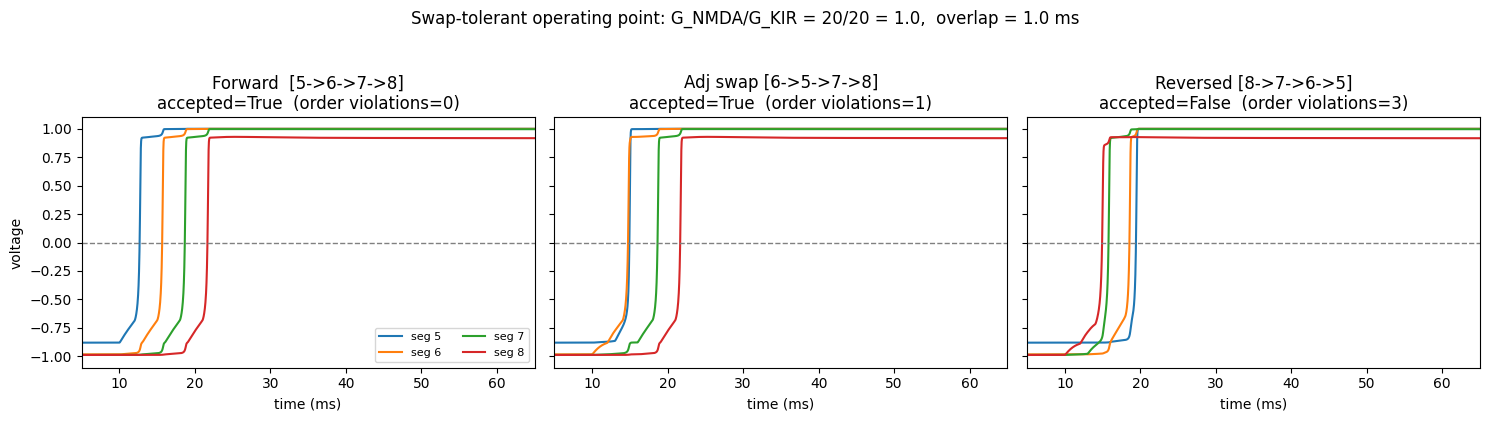

Scores  (ratio=1.0, overlap=1.0 ms)
------------------------------------------------------------------------------------------
Forward  [5->6->7->8]     accepted=True   order_violations=0  all_detected=True   final_high=True   activation[5,6,7,8]=[12.7-15.7-18.7-21.7]
Adj swap [6->5->7->8]     accepted=True   order_violations=1  all_detected=True   final_high=True   activation[5,6,7,8]=[14.9-14.8-18.7-21.7]
Reversed [8->7->6->5]     accepted=False  order_violations=3  all_detected=True   final_high=True   activation[5,6,7,8]=[19.4-18.6-15.8-14.9]


In [3]:
# Demonstrate the detector at a SWAP-TOLERANT operating point:
#   intrinsic NMDA/KIR ratio = 1.0 (G_NMDA=20, G_KIR=20), mild burst overlap.
# At this ratio the burst input is strong enough to flip each segment via its
# OWN input, so activation order reflects input order (not just the plateau
# front diffusing down the cable). That is what makes the three sequence types
# separable.

ratio_demo      = 1.0                        # G_KIR = 20/1.0 = 20  (HW2 values)
overlap_demo    = 1.0                        # ms (mild overlap, well below flooding)
onset_step_demo = overlap_to_onset(overlap_demo)

seq_defs = [
    ("Forward  [5->6->7->8]", SEQ_FORWARD,  0),  # require perfect order
    ("Adj swap [6->5->7->8]", SEQ_ADJ_SWAP, 1),  # tolerate one swap
    ("Reversed [8->7->6->5]", SEQ_REVERSED, 1),  # judged by the same accept test
]

results_base = []
for label, seq, max_v in seq_defs:
    times, V_hist = run_sequence(seq, onset_step_demo, ratio_demo)
    s = score_detection(times, V_hist, sequence_segments)
    accepted = accept_sequence(s, max_violations=max_v)
    nviol = count_order_violations(s["activation_times"])
    results_base.append((label, times, V_hist, s, accepted, nviol))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (label, times, V_hist, s, accepted, nviol) in zip(axes, results_base):
    for seg in sequence_segments:
        ax.plot(times, V_hist[:, seg], label=f"seg {seg}")
    ax.axhline(0, linestyle="--", linewidth=1, color="gray")
    ax.set_xlim(5, 65)
    ax.set_xlabel("time (ms)")
    ax.set_title(f"{label}\naccepted={accepted}  (order violations={nviol})")
axes[0].set_ylabel("voltage")
axes[0].legend(ncol=2, fontsize=8)
plt.suptitle(
    f"Swap-tolerant operating point: "
    f"G_NMDA/G_KIR = {G_NMDA:.0f}/{G_NMDA/ratio_demo:.0f} = {ratio_demo:.1f},  "
    f"overlap = {overlap_demo} ms",
    y=1.04,
)
plt.tight_layout()
plt.show()

print(f"Scores  (ratio={ratio_demo:.1f}, overlap={overlap_demo} ms)")
print("-" * 90)
for label, times, V_hist, s, accepted, nviol in results_base:
    order = "-".join(
        f"{s['activation_times'][int(seg)]:.1f}"
        if np.isfinite(s['activation_times'][int(seg)]) else "X"
        for seg in sequence_segments
    )
    print(
        f"{label:24s}  accepted={str(accepted):5}  "
        f"order_violations={nviol}  all_detected={str(s['all_detected']):5}  "
        f"final_high={str(s['final_high']):5}  activation[5,6,7,8]=[{order}]"
    )

##### Key: 
**accepted** (True/False) = The final yes/no verdict for this input. True means the dendrite treated the input as a valid version of the target sequence. A run is accepted only if every target segment fired, the last segment stayed high at the end, and the number of out-of-order pairs stayed within the allowed budget (0 for forward, 1 for the swap/reversed cases).

**order_violations** (integer) = How many neighboring pairs of the target [5, 6, 7, 8] activated out of order. It's computed by comparing the activation times against the target order: each time a later segment fires *before* the one that should precede it counts as one violation. Forward = 0, a single adjacent swap = 1, a full reversal = 3. This is the core measure of selectivity.

**all_detected** (True/False) = Whether every one of the four target segments crossed threshold at some point during the run. True just means "all four lit up"; it says nothing about the order. Used as a basic gate before order is even considered.

**final_high** (True/False) = Whether the *last* target segment (seg 8) was still above threshold at the end of the run, measured as its average voltage over the final 5 ms. It confirms the sequence ended in a latched "up" state rather than decaying away. Note: under bursts this tends to be True for every input — even reversed — so it's a sanity gate, not the thing that distinguishes a real sequence from a reversed one.

**activation[5,6,7,8]** (list) = The time in milliseconds at which each target segment first crossed threshold, listed in fixed target order 5, 6, 7, 8 (not input order). Increasing values mean the segments fired in order (e.g. forward); decreasing values mean they fired in reverse. This is the raw timing the order_violations count is derived from.

### A closer look at the burst: the NMDA residual that adds up

The operating point above works because each segment is driven by a three-spike burst, not a single spike, and the three spikes land only 2 ms apart. That spacing is the whole point. NMDA decays slowly (the paper's decay constants are 12.6, 57.3, and 372 ms), so the conductance opened by the first spike has barely faded when the second and third arrive, and the contributions sum. AMPA decays with a 3 ms time constant.

At a 2 ms spacing both channels actually sum a little while the burst is still firing, so summation by itself is not the distinction. The difference shows up in how long the summed conductance lasts after the burst ends. NMDA holds its accumulated conductance for tens of milliseconds, across the plateau window that latches the segment, while AMPA collapses back toward zero within about 10 ms.

Here, we take the exact spike times the baseline used for the first segment of the forward sequence (segment 5, firing at 10, 12, and 14 ms) and evaluate the synaptic conductance kernels those spikes produce. It compares a single spike against all three summed, and reports how much conductance remains at several times after the last spike. This residual summation is what every `simulate_dendrite` call in this notebook relies on, realized in code by `g_NMDA_vector` summing the kernels of all spike events.

Baseline burst spike times for segment 5: [10.0, 12.0, 14.0] ms  (ISI = 2.0 ms)

Residual from earlier spikes, at the instant each new burst spike fires:
  spike 1 @   10 ms   leftover NMDA = 0.000   leftover AMPA = 0.000
  spike 2 @   12 ms   leftover NMDA = 0.824   leftover AMPA = 0.930
  spike 3 @   14 ms   leftover NMDA = 1.812   leftover AMPA = 1.886

Summed conductance remaining after the last spike (t = 14 ms):
  t =   14 ms (+ 0)   NMDA = 1.812   AMPA = 1.886
  t =   19 ms (+ 5)   NMDA = 2.939   AMPA = 1.877
  t =   24 ms (+10)   NMDA = 2.729   AMPA = 0.642
  t =   34 ms (+20)   NMDA = 2.367   AMPA = 0.043
  t =   54 ms (+40)   NMDA = 1.925   AMPA = 0.000


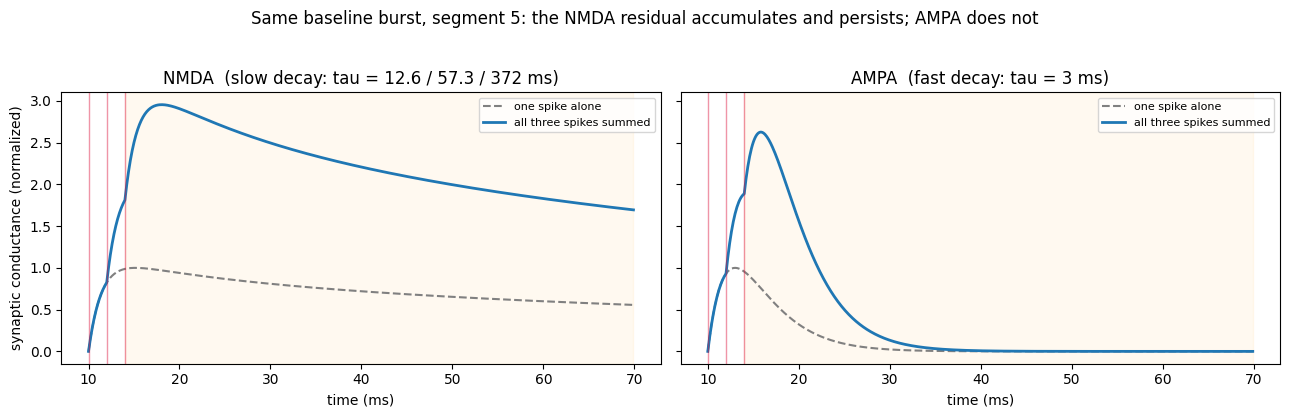


Peak summed NMDA = 2.954 vs single-spike 1.000 (2.95x).  20 ms after the burst, NMDA is still 2.367 while AMPA has fallen to 0.043.


In [4]:
# Anchor to the SAME baseline burst used in Section 2 (forward sequence,
# overlap = 1 ms). We do NOT re-simulate; we evaluate the synaptic conductance
# kernels directly, using the exact spike times the baseline injected into the
# first segment (segment 5). This isolates the residual-summation effect that
# the full simulation relies on.
from src.inputs import nmda_conductance, alpha_conductance

# Reconstruct the baseline burst timing for segment 5.
onset_step_base = overlap_to_onset(1.0)            # overlap = 1 ms, as in Section 2
_, raster_base = make_burst_sequence(
    sequence_segments=SEQ_FORWARD, start_time=start_time,
    onset_step_ms=onset_step_base, burst_len=burst_len,
    isi_ms=isi_ms, weight=weight,
)
seg5_spikes = raster_base[5]
print(f"Baseline burst spike times for segment 5: {seg5_spikes} ms  (ISI = {isi_ms} ms)\n")

def running_sum(kernel, spikes, t):
    """Conductance at time t from every spike that has already fired by t."""
    return sum(kernel(t, s) for s in spikes if s <= t)

# (1) Residual still present from earlier spikes AT the instant each new spike fires.
print("Residual from earlier spikes, at the instant each new burst spike fires:")
for i, st in enumerate(seg5_spikes):
    rn = running_sum(nmda_conductance, seg5_spikes[:i], st)
    ra = running_sum(alpha_conductance, seg5_spikes[:i], st)
    print(f"  spike {i+1} @ {st:4.0f} ms   leftover NMDA = {rn:5.3f}   leftover AMPA = {ra:5.3f}")

# (2) The real contrast: how long the SUMMED conductance lasts after the burst ends.
last = seg5_spikes[-1]
print(f"\nSummed conductance remaining after the last spike (t = {last:.0f} ms):")
for d in [0, 5, 10, 20, 40]:
    t = last + d
    print(f"  t = {t:4.0f} ms (+{d:2d})   NMDA = {running_sum(nmda_conductance, seg5_spikes, t):5.3f}"
          f"   AMPA = {running_sum(alpha_conductance, seg5_spikes, t):5.3f}")

# (3) Plot single-spike vs all-three-summed for each channel.
tgrid  = np.arange(seg5_spikes[0], seg5_spikes[0] + 60.0, 0.1)
gN_sum = np.array([running_sum(nmda_conductance, seg5_spikes, t) for t in tgrid])
gA_sum = np.array([running_sum(alpha_conductance, seg5_spikes, t) for t in tgrid])
gN_one = np.array([nmda_conductance(t, seg5_spikes[0]) for t in tgrid])
gA_one = np.array([alpha_conductance(t, seg5_spikes[0]) for t in tgrid])

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
panels = [
    (axes[0], "NMDA  (slow decay: tau = 12.6 / 57.3 / 372 ms)", gN_one, gN_sum),
    (axes[1], "AMPA  (fast decay: tau = 3 ms)",                 gA_one, gA_sum),
]
for ax, title, one, summ in panels:
    ax.plot(tgrid, one,  "--", color="gray", label="one spike alone")
    ax.plot(tgrid, summ, "-",  color="C0", lw=2, label="all three spikes summed")
    for st in seg5_spikes:
        ax.axvline(st, color="crimson", lw=1, alpha=0.45)
    ax.axvspan(last, tgrid[-1], color="orange", alpha=0.06)
    ax.set_title(title)
    ax.set_xlabel("time (ms)")
    ax.legend(fontsize=8, loc="upper right")
axes[0].set_ylabel("synaptic conductance (normalized)")
plt.suptitle("Same baseline burst, segment 5: the NMDA residual accumulates and persists; "
             "AMPA does not", y=1.03)
plt.tight_layout()
plt.show()

print(f"\nPeak summed NMDA = {gN_sum.max():.3f} vs single-spike {gN_one.max():.3f} "
      f"({gN_sum.max()/gN_one.max():.2f}x).  "
      f"20 ms after the burst, NMDA is still {running_sum(nmda_conductance, seg5_spikes, last + 20):.3f} "
      f"while AMPA has fallen to {running_sum(alpha_conductance, seg5_spikes, last + 20):.3f}.")


## Section 3: The full phase diagram

Section 2 showed the detector working at one setting. Now we will look at **across what range of settings does swap-tolerant behavior survive?** A detector that only works at one exact knob position is not robust. This section answers that by sweeping both the NMDA/KIR ratio and burst overlap duration at once and mapping the result.

We vary the **NMDA/KIR ratio** from 0.5 to 2.5 (vertical axis) against the **burst overlap** from 0 to 3.5 ms (horizontal axis). At every grid point we run all three input types, classify the outcome, and color the cell by which of the four behaviors we get:

- **Failure** (red) — the dendrite cannot even follow the forward sequence.
- **Too strict** (blue) — it follows forward but rejects the harmless single swap.
- **Swap-tolerant** (green) — the target: accepts forward and the swap, rejects the reversal.
- **Too permissive** (orange) — it accepts everything, reversal included.

We sample the ratio in fine 0.1 steps because the interesting boundaries (the thin "too strict" band in particular) are narrow and would vanish at coarser spacing.

**The white star** marks the *exact* operating point we examined in Section 2 (ratio 1.0, overlap 1.0 ms). Its location on the graph confirms that the single example we walked through sits inside the green swap-tolerant region, and we can see how much room surrounds it before the behavior changes.

Here, we run the full sweep (504 short simulations), classifies every grid point, and draws the phase diagram.

Running sweep  (504 simulations) ...
  ratio = 0.5  (G_KIR = 40.0)  done
  ratio = 0.6  (G_KIR = 33.3)  done
  ratio = 0.7  (G_KIR = 28.6)  done
  ratio = 0.8  (G_KIR = 25.0)  done
  ratio = 0.9  (G_KIR = 22.2)  done
  ratio = 1.0  (G_KIR = 20.0)  done
  ratio = 1.1  (G_KIR = 18.2)  done
  ratio = 1.2  (G_KIR = 16.7)  done
  ratio = 1.3  (G_KIR = 15.4)  done
  ratio = 1.4  (G_KIR = 14.3)  done
  ratio = 1.5  (G_KIR = 13.3)  done
  ratio = 1.6  (G_KIR = 12.5)  done
  ratio = 1.7  (G_KIR = 11.8)  done
  ratio = 1.8  (G_KIR = 11.1)  done
  ratio = 1.9  (G_KIR = 10.5)  done
  ratio = 2.0  (G_KIR = 10.0)  done
  ratio = 2.1  (G_KIR = 9.5)  done
  ratio = 2.2  (G_KIR = 9.1)  done
  ratio = 2.3  (G_KIR = 8.7)  done
  ratio = 2.4  (G_KIR = 8.3)  done
  ratio = 2.5  (G_KIR = 8.0)  done
Sweep complete.


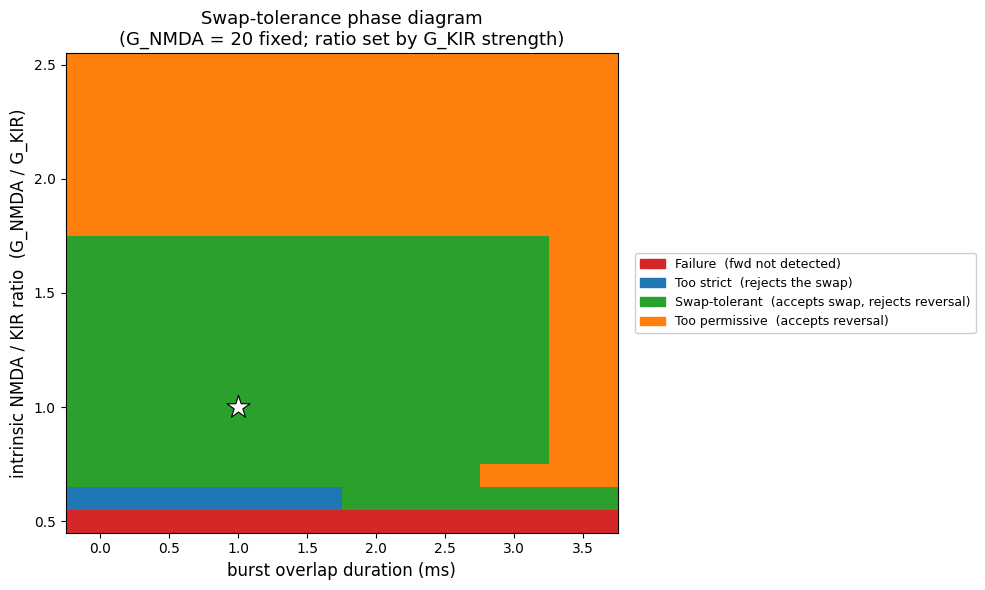

In [5]:
# Sweep the INTRINSIC NMDA/KIR ratio (G_NMDA=20 fixed, vary G_KIR) against
# burst overlap. The ratio is sampled finely (0.1) from 0.5 to 2.5 so the narrow
# too-strict band near failure is resolved; tick labels stay at 0.5 intervals.

ratios   = np.round(np.arange(0.5, 2.5001, 0.1), 2)          # 0.5 .. 2.5, fine
overlaps = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5])

# grid[i, j] = regime for (ratios[i], overlaps[j])
grid = np.zeros((len(ratios), len(overlaps)), dtype=int)

print("Running sweep  ({} simulations) ...".format(len(ratios) * len(overlaps) * 3))

for i, ratio in enumerate(ratios):
    for j, overlap in enumerate(overlaps):
        onset_step = overlap_to_onset(overlap)

        t_fwd, V_fwd = run_sequence(SEQ_FORWARD,  onset_step, ratio)
        t_adj, V_adj = run_sequence(SEQ_ADJ_SWAP, onset_step, ratio)
        t_rev, V_rev = run_sequence(SEQ_REVERSED, onset_step, ratio)

        s_fwd = score_detection(t_fwd, V_fwd, sequence_segments)
        s_adj = score_detection(t_adj, V_adj, sequence_segments)
        s_rev = score_detection(t_rev, V_rev, sequence_segments)

        # Forward must be perfectly ordered (0 swaps). Adjacent-swap and
        # reversed are judged by the SAME acceptance test (tolerate <= 1 swap):
        # the detector is selective when it accepts the swap but rejects the
        # reversal.
        fwd_pass = accept_sequence(s_fwd, max_violations=0)
        adj_pass = accept_sequence(s_adj, max_violations=1)
        rev_pass = accept_sequence(s_rev, max_violations=1)

        grid[i, j] = classify_point(fwd_pass, adj_pass, rev_pass)

    print(f"  ratio = {ratio:.1f}  (G_KIR = {G_NMDA/ratio:.1f})  done")

print("Sweep complete.")

# -- Phase diagram --------------------------------------------------------------
REGIME_COLORS = ["#d62728", "#1f77b4", "#2ca02c", "#ff7f0e"]
REGIME_LABELS = [
    "Failure  (fwd not detected)",
    "Too strict  (rejects the swap)",
    "Swap-tolerant  (accepts swap, rejects reversal)",
    "Too permissive  (accepts reversal)",
]
cmap = plt.matplotlib.colors.ListedColormap(REGIME_COLORS)


def make_edges(centers):
    """Bin edges for pcolormesh from cell centers."""
    c = np.asarray(centers, dtype=float)
    edges = np.empty(len(c) + 1)
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0]    = c[0]  - (c[1]  - c[0])  / 2
    edges[-1]   = c[-1] + (c[-1] - c[-2]) / 2
    return edges


overlap_edges = make_edges(overlaps)
ratio_edges   = make_edges(ratios)

fig, ax = plt.subplots(figsize=(10, 6))
ax.pcolormesh(overlap_edges, ratio_edges, grid, cmap=cmap, vmin=-0.5, vmax=3.5)

ax.set_xlabel("burst overlap duration (ms)", fontsize=12)
ax.set_ylabel("intrinsic NMDA / KIR ratio  (G_NMDA / G_KIR)", fontsize=12)
ax.set_title(
    "Swap-tolerance phase diagram\n(G_NMDA = 20 fixed; ratio set by G_KIR strength)",
    fontsize=13,
)
ax.set_xticks(overlaps)
ax.set_yticks(np.arange(0.5, 2.5001, 0.5))   # tick labels every 0.5

patches = [
    mpatches.Patch(color=REGIME_COLORS[k], label=REGIME_LABELS[k])
    for k in range(4)
]
ax.legend(
    handles=patches, loc="center left", bbox_to_anchor=(1.02, 0.5),
    fontsize=9, framealpha=0.95,
)

# Star marks the Section-2 demo operating point.
ax.scatter(
    [overlap_demo], [ratio_demo],
    marker="*", s=300, color="white", edgecolor="black", linewidth=0.8, zorder=5,
)

plt.tight_layout()
plt.show()

### Reading the exact regime boundaries off the grid

The phase diagram above is easy to read at a glance but hard to pull precise numbers from. Here, we take a look at the overall ratio span and overlap span, and then the ratio band at each overlap column. We break it down by overlap because the boundaries shift as the bursts overlap more, so a single range would hide that structure.

In [6]:
# Read the exact extent of each regime straight from `grid` (built in the sweep
# above). No new simulations are run. Grid axes: rows = NMDA/KIR ratio
# (`ratios`), columns = burst overlap in ms (`overlaps`).

REGIME_NAMES = [
    "Failure        (red)",
    "Too strict     (blue)",
    "Swap-tolerant  (green)",
    "Too permissive (orange)",
]


def contiguous_runs(vals):
    """Group a sorted list of ratios into contiguous 0.1-spaced runs."""
    runs = []
    for v in vals:
        if runs and round(v - runs[-1][1], 2) <= 0.1 + 1e-9:
            runs[-1][1] = v
        else:
            runs.append([v, v])
    return runs


def fmt_runs(runs):
    return ", ".join(f"{a:.1f}" if a == b else f"{a:.1f}-{b:.1f}" for a, b in runs)


print("Exact regime extents  (G_NMDA = 20 fixed; ratio = 20 / G_KIR)")
print("rows = NMDA/KIR ratio,  columns = burst overlap (ms)")
print("=" * 66)

for code, name in enumerate(REGIME_NAMES):
    mask = grid == code
    if not mask.any():
        print(f"\n{name}:  not present in this grid")
        continue
    rs = ratios[mask.any(axis=1)]
    ov = overlaps[mask.any(axis=0)]
    print(f"\n{name}")
    print(f"  ratio range  : {rs.min():.1f} - {rs.max():.1f}")
    print(f"  overlap range: {ov.min():.1f} - {ov.max():.1f} ms")
    print("  ratio band at each overlap:")
    for j, o in enumerate(overlaps):
        col = sorted(ratios[grid[:, j] == code])
        if col:
            print(f"    overlap {o:>3.1f} ms : ratio {fmt_runs(contiguous_runs(col))}")

Exact regime extents  (G_NMDA = 20 fixed; ratio = 20 / G_KIR)
rows = NMDA/KIR ratio,  columns = burst overlap (ms)

Failure        (red)
  ratio range  : 0.5 - 0.5
  overlap range: 0.0 - 3.5 ms
  ratio band at each overlap:
    overlap 0.0 ms : ratio 0.5
    overlap 0.5 ms : ratio 0.5
    overlap 1.0 ms : ratio 0.5
    overlap 1.5 ms : ratio 0.5
    overlap 2.0 ms : ratio 0.5
    overlap 2.5 ms : ratio 0.5
    overlap 3.0 ms : ratio 0.5
    overlap 3.5 ms : ratio 0.5

Too strict     (blue)
  ratio range  : 0.6 - 0.6
  overlap range: 0.0 - 1.5 ms
  ratio band at each overlap:
    overlap 0.0 ms : ratio 0.6
    overlap 0.5 ms : ratio 0.6
    overlap 1.0 ms : ratio 0.6
    overlap 1.5 ms : ratio 0.6

Swap-tolerant  (green)
  ratio range  : 0.6 - 1.7
  overlap range: 0.0 - 3.5 ms
  ratio band at each overlap:
    overlap 0.0 ms : ratio 0.7-1.7
    overlap 0.5 ms : ratio 0.7-1.7
    overlap 1.0 ms : ratio 0.7-1.7
    overlap 1.5 ms : ratio 0.7-1.7
    overlap 2.0 ms : ratio 0.6-1.7
    over